# 第三阶段 A：约束 MPC 教师闭环验证

## 研究问题

在 Chen2020、25 ℃、10%–80% SOC 范围内，MPC 能否在电流、端电压和平均温度约束下生成可行充电轨迹，并把同一控制器施加到独立 DFN 虚拟电池后仍然守约束？

**第一版验收标准**：到达80% SOC容差范围；DFN不超过4.20 V、35 ℃和10 A；优化成功率、预测可行率均不低于95%。本 notebook 不训练 DNN。

## 方法概览

MPC状态采用

\[
x_k=[SOC_k,v_{1,k},v_{2,k},T_{c,k},T_{s,k},I_{k-1}],
\]

输出第一步最优充电电流。第二阶段只验证了平均温度

\[
T_{avg}=0.8T_c+0.2T_s,
\]

因此本阶段只对平均温度作有依据的约束，不能把两个热节点解释成已经验证的核心/表面真实温度。

DFN最终检查4.20 V和35 ℃；MPC内部使用4.14 V和33.5 ℃，为降阶模型误差预留余量。

## 实验计划

1. 读取第二阶段参数、OCV和验证闸门；
2. 在降阶模型上运行MPC闭环；
3. 将每次控制动作逐步施加到Chen2020 DFN；
4. 与现有1C、1.5C、2C CC–CV基线比较；
5. 检查约束、优化可行性和计算时间，再决定是否进入DNN数据生成。

In [1]:
from pathlib import Path
import json
import os
import pandas as pd
from IPython.display import Image, display

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")

# 无论从项目根目录还是 notebooks 目录启动，都自动定位项目根目录。
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase3.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.phase3_config import load_phase_three_config
from battery_fast_charge.phase3_runner import run_phase_three

config = load_phase_three_config(PROJECT_ROOT / "configs" / "phase3.yaml")
print(f"研究：{config.study_name}")
print(f"SOC范围：{config.battery.initial_soc:.0%} → {config.battery.target_soc:.0%}")
print(f"控制周期：{config.control.control_interval_s:g} s")

研究：chen2020_phase3_mpc_teacher
SOC范围：10% → 80%
控制周期：5 s


## 运行或读取正式结果

正式结果已经保存在项目中。默认只读取，几秒内即可完整运行本 notebook。若把 `RUN_PHASE3` 改为 `True`，将从10% SOC重新运行降阶闭环和逐步DFN闭环，通常需要数分钟。

In [2]:
RUN_PHASE3 = False

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "phase3_mpc_metrics.json"
comparison_path = PROJECT_ROOT / "outputs" / "metrics" / "phase3_controller_comparison.csv"
reduced_path = PROJECT_ROOT / "data" / "phase3" / "mpc_reduced_closed_loop.csv"
dfn_path = PROJECT_ROOT / "data" / "phase3" / "mpc_chen2020_dfn_closed_loop.csv"

required = [metrics_path, comparison_path, reduced_path, dfn_path]
if RUN_PHASE3 or any(not path.exists() for path in required):
    run_phase_three(config, PROJECT_ROOT)

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
comparison = pd.read_csv(comparison_path)
reduced = pd.read_csv(reduced_path)
dfn = pd.read_csv(dfn_path)

## 约束与安全余量

In [3]:
constraint_table = pd.DataFrame([
    {
        "quantity": "Terminal voltage [V]",
        "MPC internal limit": config.constraints.mpc_maximum_voltage_v,
        "DFN physical check": config.constraints.physical_maximum_voltage_v,
        "reserved margin": config.constraints.voltage_uncertainty_margin_v,
    },
    {
        "quantity": "Average temperature [degC]",
        "MPC internal limit": config.constraints.mpc_maximum_temperature_c,
        "DFN physical check": config.constraints.physical_maximum_temperature_c,
        "reserved margin": config.constraints.temperature_uncertainty_margin_c,
    },
])
display(constraint_table)

,quantity,MPC internal limit,DFN physical check,reserved margin
0,Terminal voltage [V],4.14,4.2,0.06
1,Average temperature [degC],33.50,35.0,1.50


## 闭环结果图

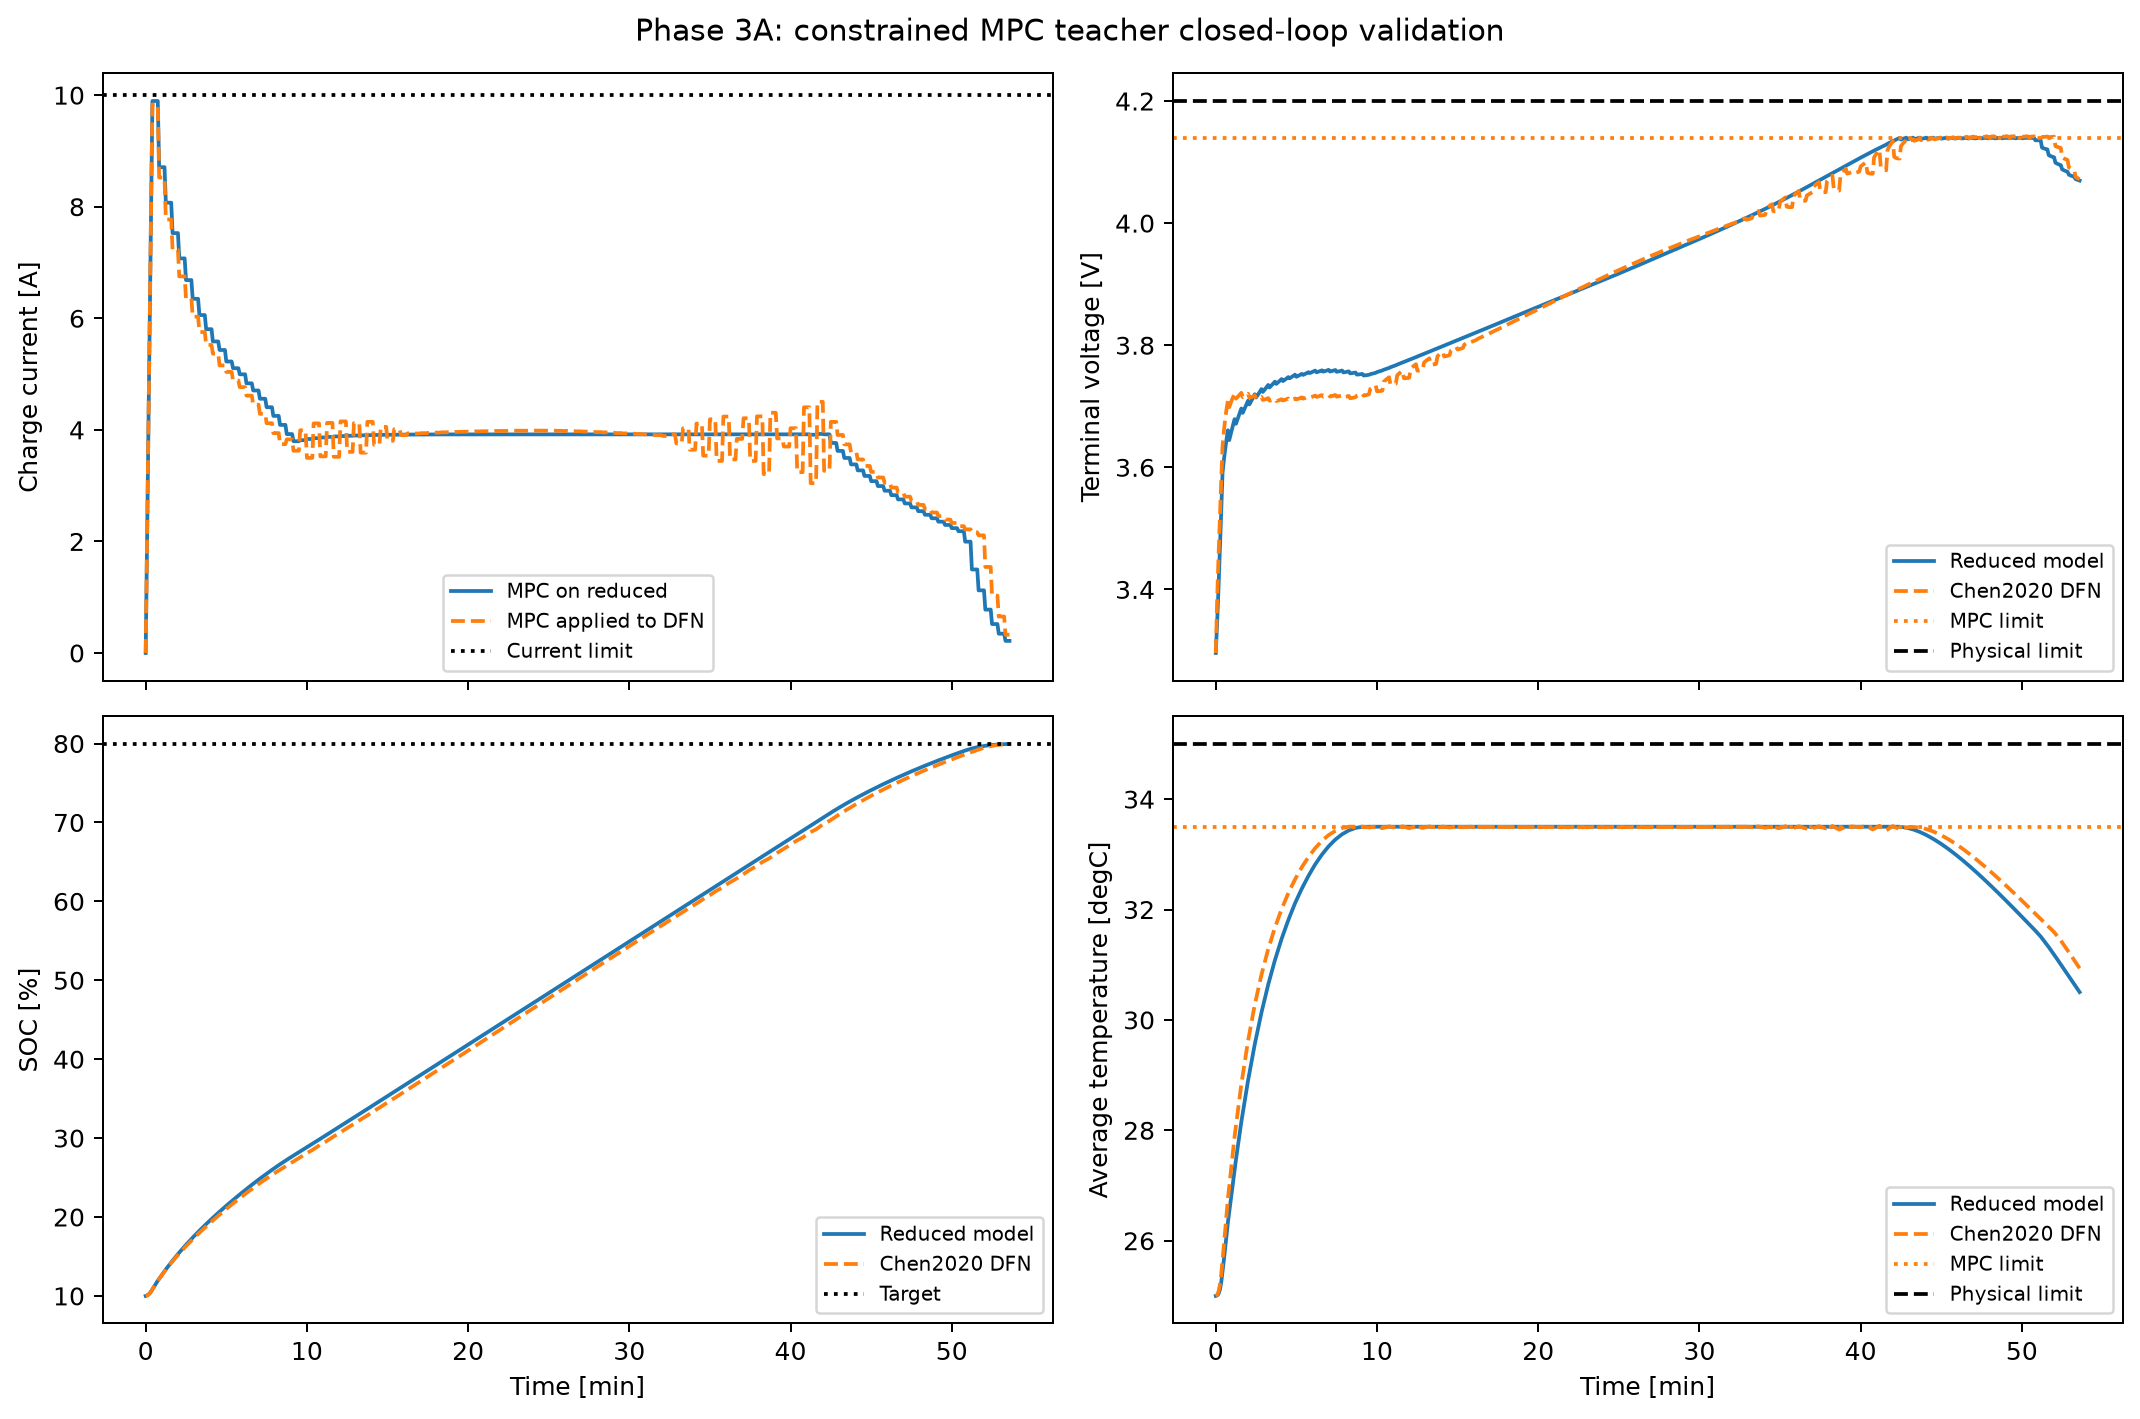

In [4]:
display(Image(filename=str(
    PROJECT_ROOT / "outputs" / "figures" / "phase3_mpc_closed_loop.png"
)))

图的阅读顺序：

- 左上：MPC先平滑升流，接近温度或电压边界后主动降流；
- 右上：橙色虚线是MPC内部4.14 V，黑线是DFN最终4.20 V边界；
- 左下：SOC到达80%容差范围；
- 右下：MPC把降阶预测压在33.5 ℃附近，DFN仍低于35 ℃。

## 数值汇总

In [5]:
display(comparison.round(4))

summary = pd.DataFrame([
    {
        "plant": "Reduced model",
        "time_min": metrics["reduced_closed_loop"]["charge_time_min"],
        "max_voltage_v": metrics["reduced_closed_loop"]["maximum_voltage_v"],
        "max_temperature_c": metrics["reduced_closed_loop"]["maximum_temperature_c"],
        "optimizer_success_%": 100 * metrics["reduced_closed_loop"]["optimizer_success_fraction"],
        "fallback_count": metrics["reduced_closed_loop"]["fallback_count"],
    },
    {
        "plant": "Chen2020 DFN",
        "time_min": metrics["dfn_closed_loop"]["charge_time_min"],
        "max_voltage_v": metrics["dfn_closed_loop"]["maximum_voltage_v"],
        "max_temperature_c": metrics["dfn_closed_loop"]["maximum_temperature_c"],
        "optimizer_success_%": 100 * metrics["dfn_closed_loop"]["optimizer_success_fraction"],
        "fallback_count": metrics["dfn_closed_loop"]["fallback_count"],
    },
])
display(summary.round(4))

,controller,plant,reached_target_soc,charge_time_min,maximum_voltage_v,maximum_temperature_c
0,CC-CV 1C,Chen2020 DFN,True,42.8117,4.2000,37.5054
1,CC-CV 1.5C,Chen2020 DFN,True,31.0521,4.2000,46.5032
2,CC-CV 2C,Chen2020 DFN,True,26.4732,4.2000,54.2589
3,Constrained MPC,reduced_model,True,53.5833,4.1400,33.5000
4,Constrained MPC,chen2020_dfn,True,53.5833,4.1425,33.5167


,plant,time_min,max_voltage_v,max_temperature_c,optimizer_success_%,fallback_count
0,Reduced model,53.5833,4.1400,33.5000,100.0,0
1,Chen2020 DFN,53.5833,4.1425,33.5167,100.0,0


## 为什么 MPC 比当前 CC–CV 更慢？

In [6]:
baseline = comparison[comparison["controller"].str.startswith("CC-CV")].copy()
baseline["temperature_excess_over_35C"] = (
    baseline["maximum_temperature_c"]
    - config.constraints.physical_maximum_temperature_c
)
display(baseline[[
    "controller", "charge_time_min", "maximum_temperature_c",
    "temperature_excess_over_35C"
]].round(3))

,controller,charge_time_min,maximum_temperature_c,temperature_excess_over_35C
0,CC-CV 1C,42.812,37.505,2.505
1,CC-CV 1.5C,31.052,46.503,11.503
2,CC-CV 2C,26.473,54.259,19.259


1C、1.5C和2C CC–CV分别更快，但三者在现有Chen2020集总热仿真中都超过35 ℃。因此它们不是与当前MPC同约束的可行对照。当前结果证明的是“MPC找到一条守35 ℃约束的轨迹”，不是“MPC已经快于CC–CV”。下一步应增加同样受35 ℃保护的CC–CV或温控基线，才能公平比较充电时间。

## 验收判断和下一步

In [7]:
dfn_metrics = metrics["dfn_closed_loop"]
decision = pd.Series({
    "Reached target SOC": dfn_metrics["reached_target_soc"],
    "Voltage constraint satisfied": not dfn_metrics["voltage_limit_exceeded"],
    "Temperature constraint satisfied": not dfn_metrics["temperature_limit_exceeded"],
    "Current constraint satisfied": not dfn_metrics["current_limit_exceeded"],
    "Optimizer success gate passed": (
        dfn_metrics["optimizer_success_fraction"]
        >= config.validation.minimum_optimizer_success_fraction
    ),
    "Phase 3A passed": metrics["success"],
})
display(decision.to_frame("result"))

,result
Reached target SOC,True
Voltage constraint satisfied,True
Temperature constraint satisfied,True
Current constraint satisfied,True
Optimizer success gate passed,True
Phase 3A passed,True


## 结论与边界

- 第三阶段A通过：教师MPC可以进入批量数据生成准备；
- 下一步不能直接随意采样状态，应先定义“可达状态域”和按轨迹划分的数据集；
- 训练标签必须排除求解失败或不可行样本，并保存活跃约束；
- 当前仍只能称为平均温度安全约束快速充电，不能称为核心温度安全或寿命最优；
- DNN训练完成后仍必须回到DFN做随机初始状态闭环验证，不能只比较电流回归误差。